# Phase 6 â€” Decision-Engine Backtest

Everything up to Phase 5 validated the *prediction model* (notebooks/06_model_comparison.ipynb: RÂ²=0.317 on a held-out season). This notebook validates the *decision engine* itself â€” the transfer plan, captain choice, and squad optimizer â€” by simulating a full season week by week using only leak-free, at-the-time predictions, then scoring the recommendations against what actually happened.

Season: **2025-26**, the same season `src.models.train` holds out entirely from training â€” a genuine backtest, not an in-sample fit. Three tracks are simulated in parallel from the same starting squad:

1. **Full decision engine** â€” MILP squad pick at GW2, then every week: the greedy transfer plan, auto-substitution, and captain choice, all driven by the model's predictions.
2. **Static squad** â€” the *same* starting squad, never transferred again; auto-sub/captain still prediction-driven. Isolates the transfer plan's marginal value.
3. **Static squad, oracle picks** â€” the same frozen squad, but auto-sub/captain are chosen with *actual* results (hindsight) instead of predictions. A same-squad ceiling that isolates how much is left on the table by imperfect weekly judgment vs. squad composition itself.

**Known simplifications** (see `src/validation/backtest.py` and README): no historical injury/availability data survives in the archive (every player is treated as selectable every week); no reactive real-FPL auto-substitution for a starter who blanks; the fixture-difficulty multi-week horizon isn't used here (it needs live-ingested fixture data 2026/27 doesn't share with historical seasons) â€” this is single-gameweek-horizon, same as the live dashboard's default.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src.validation.backtest import run_backtest, summarize

pd.set_option("display.width", 160)
result = run_backtest()

Using model_id=43 (random_forest), 36 features, from C:\Users\USER\fergies-regression\models\total_points_direct_random_forest.joblib


Backtesting 2025-26, GW2-GW38 (37 gameweeks)...


Initial squad (GW2): 99.8m spent, predicted starting XI (incl. captain) = 60.85


## Season totals

In [2]:
summarize(result)

totals = pd.DataFrame({
    "Track": ["Full decision engine", "Static squad (no transfers)", "Static squad, oracle picks"],
    "Season points": [
        result["full_engine_points"].sum(),
        result["static_squad_points"].sum(),
        result["static_oracle_points"].sum(),
    ],
    "Points per GW": [
        result["full_engine_points"].mean(),
        result["static_squad_points"].mean(),
        result["static_oracle_points"].mean(),
    ],
})
display(totals.round(1))


=== Season totals (37 gameweeks) ===
  Full decision engine               1791.0 pts
  Static squad (no transfers)        1445.0 pts
  Static squad, oracle picks         1637.0 pts

Transfer plan's contribution (engine - static):        +346.0 pts
Same-squad judgment ceiling left on the table:          +192.0 pts
Total transfers made across the season: 36


,Track,Season points,Points per GW
0,Full decision engine,1791.0,48.4
1,Static squad (no transfers),1445.0,39.1
2,"Static squad, oracle picks",1637.0,44.2


## Cumulative points across the season

If the transfer plan is adding real value, the full-engine line should pull steadily away from the static-squad line as the season goes on.

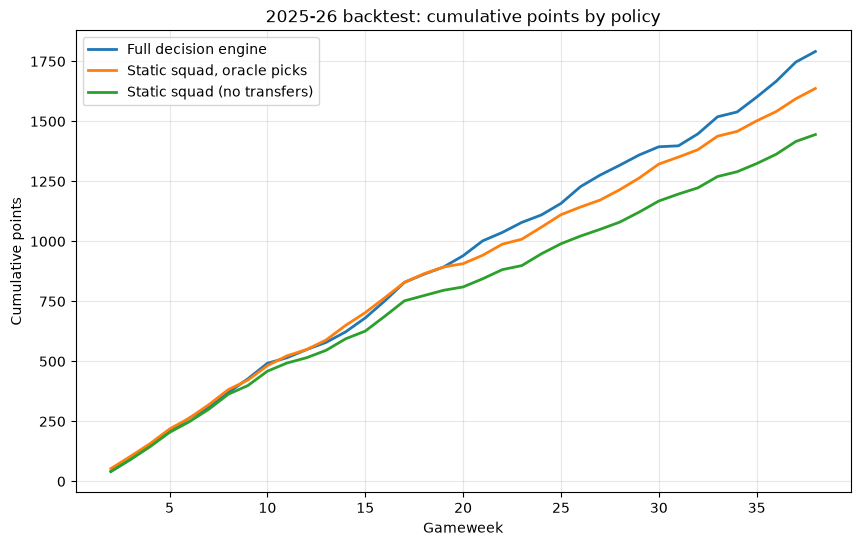

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(result["GW"], result["full_engine_cumulative"], label="Full decision engine", linewidth=2)
ax.plot(result["GW"], result["static_oracle_cumulative"], label="Static squad, oracle picks", linewidth=2)
ax.plot(result["GW"], result["static_squad_cumulative"], label="Static squad (no transfers)", linewidth=2)
ax.set_xlabel("Gameweek")
ax.set_ylabel("Cumulative points")
ax.set_title("2025-26 backtest: cumulative points by policy")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Weekly detail

In [4]:
display(result[[
    "GW", "transfers_made", "hit_cost", "free_transfers_after",
    "full_engine_points", "full_engine_captain",
    "static_squad_points", "static_oracle_points",
]])

,GW,transfers_made,hit_cost,free_transfers_after,full_engine_points,full_engine_captain,static_squad_points,static_oracle_points
0,2,0,0,1,41.0,Erling Haaland,41.0,53.0
1,3,1,0,1,50.0,Erling Haaland,50.0,51.0
2,4,1,0,1,57.0,Erling Haaland,53.0,53.0
3,5,1,0,1,59.0,Erling Haaland,60.0,61.0
4,6,1,0,1,56.0,Erling Haaland,44.0,45.0
5,7,1,0,1,45.0,Erling Haaland,52.0,56.0
6,8,1,0,1,62.0,Erling Haaland,63.0,63.0
7,9,1,0,1,57.0,Erling Haaland,36.0,40.0
8,10,1,0,1,65.0,Erling Haaland,60.0,60.0
9,11,1,0,1,23.0,Erling Haaland,34.0,41.0


## Interpretation

Comparing the three tracks decomposes "how good is Fergie's Regression" into two separate questions:

- **Full engine vs. static squad** â€” the value of *making transfers at all*, using the model's own judgment for who to buy and sell.
- **Static oracle vs. static squad** â€” holding the squad fixed, the ceiling available from *perfect* weekly captain/bench choices vs. the model's actual (imperfect) weekly choices. This is the gap the model's captain/bench judgment leaves on the table, independent of squad quality.

A full engine total well above both static tracks says the transfer plan is the dominant value driver â€” more valuable than even perfect weekly lineup picks would be from a frozen squad. That's a meaningfully different (and more useful) finding than the RÂ² numbers in notebook 06 alone: it says the *decisions*, not just the *predictions*, hold up against a real season.